# Gierer–Meinhardt 2D Demo

In this notebook, we simulate the Gierer–Meinhardt reaction–diffusion system in two spatial dimensions using the AB2–AM2 scheme.

The aim is to show that the same numerical framework can be applied to another classical activator–inhibitor model. Compared with the Schnakenberg system, the Gierer–Meinhardt model can produce more strongly localised structures because of the nonlinear activator feedback term.

The observed pattern depends on:
- the diffusion ratio $d$,
- the reaction parameters $a$ and $b$,
- the domain size,
- and the nonlinear interaction between growing spatial modes.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import numpy as np
import matplotlib.pyplot as plt

from src.solvers import AB2AM2Solver2D
from src.models import GiererMeinhardtModel
from src.visualiser import plot_2D_both, plot_2D_U, plot_2D_cases, animate_2D_both

## 1. Single 2D simulation

We begin with a single two-dimensional simulation on a square domain. The initial condition is a small random perturbation of the homogeneous steady state.

For the Gierer–Meinhardt model, we use a parameter set for which the homogeneous steady state is stable without diffusion but can become unstable once diffusion is introduced.

In [2]:
params = {
    "a": 0.1,
    "b": 1.0,
    "gamma": 2.0,
    "d": 20.0
}

solver = AB2AM2Solver2D(
    model=GiererMeinhardtModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=100,
    Ny=100,
    T=100,
    dt=0.1,
    save_every=20
)

t, U, V, x, y, X, Y = solver.run(p_type="random")

print("Ran successfully:", U.shape)

Ran successfully: (51, 100, 100)


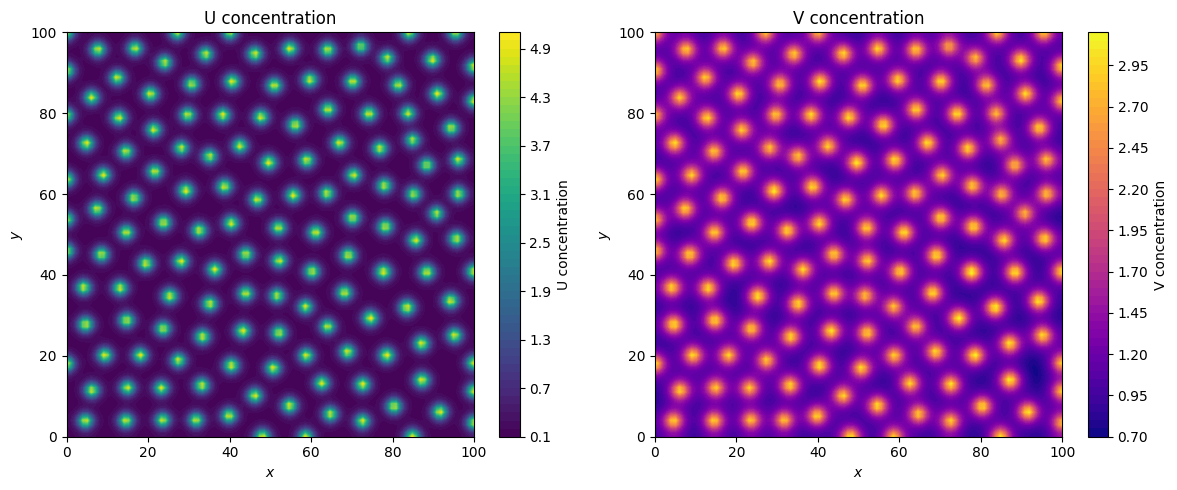

In [3]:
plot_2D_both(X, Y, U[-1], V[-1])

## 2. Changing domain size

We next compare simulations on two different rectangular domains. The aim is not to classify all possible Gierer–Meinhardt morphologies, but simply to show that changing the domain dimensions changes the visible spatial structure.

In particular, the square domain supports localised spot or peak-like patterns, while the long thin domain encourages banded or stripe-like structure.

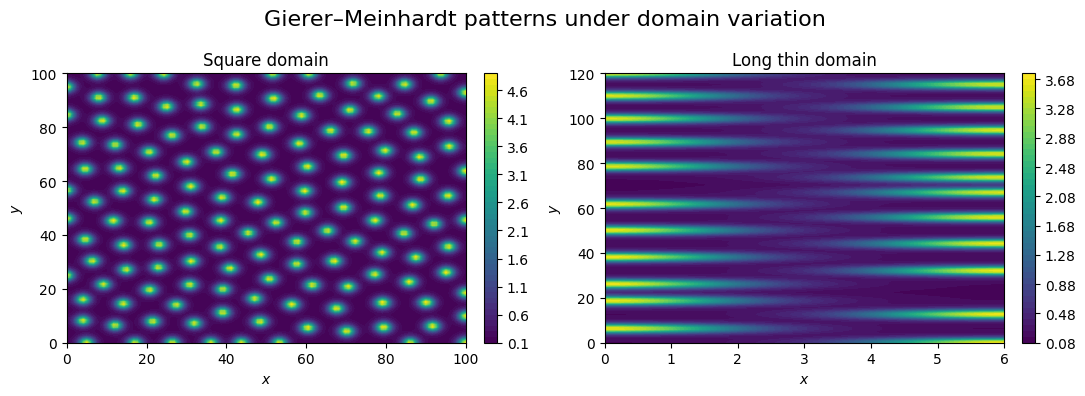

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Localised peaks
params = {"a": 0.1, "b": 1.0, "gamma": 2.0, "d": 20.0}
solver = AB2AM2Solver2D(
    model=GiererMeinhardtModel,
    params=params,
    Lx=100, Ly=100,
    Nx=120, Ny=120,
    T=150, dt=0.1
)

t, U, V, x, y, X, Y = solver.run(p_type="random")
c1 = axes[0].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[0].set_title("Square domain")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
plt.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)


# Stripes / bands
params = {
    "a": 0.1,
    "b": 1.0,
    "gamma": 2.0,
    "d": 15.0   # slightly lower → sharper bands
}

solver = AB2AM2Solver2D(
    model=GiererMeinhardtModel,
    params=params,
    Lx=6, Ly=120,     # strong aspect ratio → forces bands
    Nx=60, Ny=180,    # better resolution in thin direction
    T=600,            # enough time to fully settle
    dt=0.05,          # improves stability + sharpness
    save_every=50
)

np.random.seed(0)  # reproducible pattern


t, U, V, x, y, X, Y = solver.run(p_type="random")
c2 = axes[1].contourf(X, Y, U[-1], cmap="viridis", levels=50)
axes[1].set_title("Long thin domain")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
plt.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Gierer–Meinhardt patterns under domain variation", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Comparing diffusion ratios

We now compare several diffusion ratios while keeping the reaction parameters fixed. This gives a visual sense of how differential diffusion affects the final pattern.

In these simulations, increasing the diffusion ratio $d$ appears to make the pattern less densely packed. The peaks become more widely separated, and the spatial structure looks more regular as $d$ increases.

This is consistent with the idea that changing $d$ changes which spatial modes are amplified, but in this demo we treat it mainly as a numerical observation rather than deriving the full mode-selection behaviour again.

In [4]:
d_vals = [10, 20, 40]
results = {}

for d_val in d_vals:
    params = {
        "a": 0.1,
        "b": 1.0,
        "gamma": 2.0,
        "d": d_val
    }

    solver = AB2AM2Solver2D(
        model=GiererMeinhardtModel,
        params=params,
        Lx=100,
        Ly=100,
        Nx=100,
        Ny=100,
        T=100,
        dt=0.1,
        save_every=50
    )

    t, U, V, x, y, X, Y = solver.run(p_type="random")
    results[d_val] = (X, Y, U[-1], V[-1])

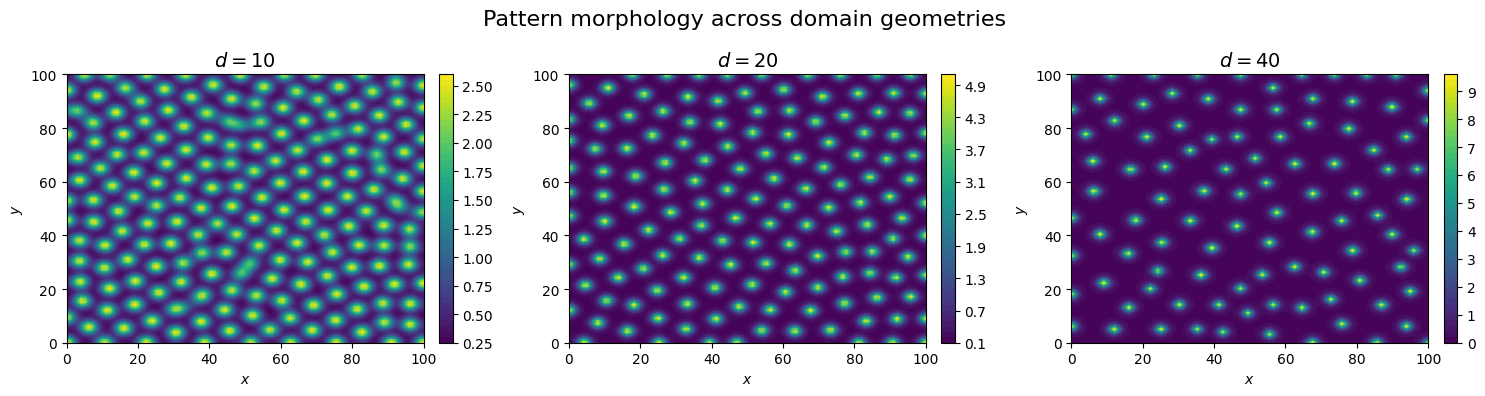

In [5]:
cases = []

for d_val in d_vals:
    X, Y, U_final, V_final = results[d_val]
    cases.append((X, Y, U_final, fr"$d = {d_val}$"))

plot_2D_cases(cases)

## 4. Animation

Finally, we save a GIF of the evolving $U$ and $V$ fields. This visualises how the initial perturbation develops into a spatially structured state.

In [6]:
params = {
    "a": 0.1,
    "b": 1.0,
    "gamma": 2.0,
    "d": 20.0
}

solver = AB2AM2Solver2D(
    model=GiererMeinhardtModel,
    params=params,
    Lx=100,
    Ly=100,
    Nx=100,
    Ny=100,
    T=100,
    dt=0.1,
    save_every=10
)

t, U_hist, V_hist, x, y, X, Y = solver.run(p_type="random")

animate_2D_both(
    X,
    Y,
    U_hist,
    V_hist,
    filename="../../outputs/gifs/gierer_meinhardt_2D_both.gif",
    fps=8,
    title="Gierer–Meinhardt: U and V concentration"
)

## 5. Conclusion

The Gierer–Meinhardt simulations show that the same AB2–AM2 framework can be applied to another classical activator–inhibitor system.

For the chosen parameters, small random perturbations of the homogeneous steady state evolve into spatially structured patterns. Compared with the Schnakenberg system, the Gierer–Meinhardt model tends to produce more localised and sharper structures, reflecting the strong nonlinear feedback in the activator term.

Changing the diffusion ratio or domain size alters the final pattern, highlighting the role of both reaction kinetics and admissible spatial modes in pattern formation.

Overall, this provides a useful intermediate comparison between the more regular Schnakenberg patterns and the more sensitive, intricate behaviour observed in the substrate–inhibitor model.